## **Modelación del Modelo**

* En este capítulo se aborda el proceso de modelación del precio de los vehículos, así como la selección de las variables más relevantes para el desempeño del modelo. Si bien en etapas previas del análisis exploratorio se identificó que variables como el año del vehículo y el kilometraje presentan una fuerte influencia sobre el precio, en esta fase se evalúa su impacto dentro del modelo predictivo, junto con otras variables categóricas y numéricas.

* Es importante destacar que, en el mercado automotriz, los vehículos nuevos experimentan una depreciación significativa, cercana al 40%, incluso cuando han recorrido pocos kilómetros fuera de la agencia. Este comportamiento justifica la inclusión del año y del kilometraje como variables clave, ya que capturan tanto el efecto del paso del tiempo como el desgaste del vehículo.

* Durante el proceso de modelación, se analizó el comportamiento del modelo ante distintas combinaciones de variables, evaluando su capacidad de generalización mediante métricas como el coeficiente de determinación ($R^2$) y validación cruzada. Asimismo, se examinó la presencia de sobreajuste (overfitting) y subajuste (underfitting), comparando el desempeño del modelo en los conjuntos de entrenamiento, validación y prueba.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/dataset/car_sales_data_clean.csv')

In [4]:
df.head()

,Fabricante,Modelo,Motor,Combustible,Año,Kilometraje,Precio
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,VW,Polo,1.0,Petrol,2006,127869,4101
4,Ford,Focus,1.4,Petrol,2018,33603,29204


##

## **Partición del conjunto de datos**

In [5]:
X = df.drop(['Precio'], axis=1)
y = df['Precio']

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.25,random_state=42)

* El conjunto de datos se dividió en tres subconjuntos: **entrenamiento**, **validación** y **prueba**. Inicialmente, se reservó el 20% de los datos para el conjunto de prueba, el cual se utilizó exclusivamente para evaluar el desempeño final del modelo. Posteriormente, el 80% restante se dividió en un 75% para entrenamiento y un 25% para validación, resultando en una partición final de 60% entrenamiento, 20% validación y 20% prueba.

## **Regresión lineal múltiple**

* La **regresión lineal múltiple** es un modelo estadístico que permite estimar el valor de una variable dependiente a partir de dos o más variables independientes. A diferencia de la regresión lineal simple, este modelo considera que el fenómeno a predecir está influenciado por varios factores al mismo tiempo.

* En el contexto automotriz, el precio de un vehículo no depende de una sola característica, sino de una combinación de factores como el fabricante, el modelo, el tipo de motor y el año de fabricación.

* El modelo busca encontrar los valores de los coeficientes **$β$** que minimizan la suma de los errores entre los valores reales y los valores predichos. Para ello, se utiliza el método de mínimos cuadrados ordinarios (OLS), el cual ajusta una recta (o hiperplano) que se aproxima lo mejor posible a los datos observados.



In [8]:
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [9]:
num_features = [ 'Motor','Año','Kilometraje']
cat_features = ['Fabricante', 'Modelo','Combustible']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [11]:
lm = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

In [12]:
lm.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Motor', 'Año',
                                                   'Kilometraje']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fabricante', 'Modelo',
                                                   'Combustible'])])),
                ('model', LinearRegression())])

## **Métricas**

### **Coeficiente de determinación**

In [13]:
lm.score(X_train,y_train)

0.715679386108182

In [14]:
lm.score(X_test,y_test)

0.7186731365962528

In [15]:
lm.score(X_val,y_val)

0.7086490860985161

In [16]:
y_train_pred = lm.predict(X_train)
y_test_pred = lm.predict(X_test)
y_val_pred = lm.predict(X_val)

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score

### **Error absoluto medio**

In [18]:
print('MAE train: ',mean_absolute_error(y_train,y_train_pred))
print('MAE test: ',mean_absolute_error(y_test,y_test_pred))
print('MAE val: ',mean_absolute_error(y_val,y_val_pred))

MAE train:  5873.103822694472
MAE test:  5784.486878730164
MAE val:  6033.519244934577


* A pesar de realizar un proceso de limpieza y depuración de datos, el modelo de regresión lineal múltiple únicamente alcanzó un **$R²$** cercano a **0.70**, lo cual indica un poder explicativo moderado sobre la variabilidad del precio. Asimismo, el error absoluto medio (MAE) se mantuvo por encima de 5,000 dólares, lo que sugiere que las predicciones aún presentan una desviación considerable respecto a los valores reales del mercado.

* Debido a este comportamiento, en la siguiente iteración del modelo se optará por mantener la regresión lineal múltiple, pero **aplicando una transformación logarítmica** a la variable objetivo (precio). Esta transformación busca reducir la asimetría de la distribución, mitigar el impacto de valores atípicos y estabilizar la varianza, con el objetivo de mejorar tanto la capacidad explicativa del modelo como la precisión de las predicciones en términos reales

## **Regresión lineal múltiple con transformación logaritmica**

In [21]:
lmlog = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', LinearRegression())
    ]),
    func=np.log,
    inverse_func=np.exp
)

In [22]:
lmlog.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>,
                           regressor=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       StandardScaler(),
                                                                                       ['Motor',
                                                                                        'Año',
                                                                                        'Kilometraje']),
                                                                                      ('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore'),
                                                                                       ['Fabricante',
                                                                                        'Modelo',
                                                                                        'Combustible'])])),
                                                     ('model',
                                                      LinearRegression())]))

La función **TransformedTargetRegressor** permite aplicar una transformación matemática directamente sobre la variable objetivo (target) sin necesidad de modificar manualmente los datos originales.


* La función func = np.log transforma el precio a escala logarítmica durante el entrenamiento.

* El modelo (en este caso una Regresión Lineal) aprende sobre esta escala transformada, lo que:

* Reduce la asimetría del target

* Disminuye el impacto de valores extremos

* Linealiza relaciones no lineales (como la depreciación de los autos)

Posteriormente:

La función inverse_func = np.exp revierte automáticamente la predicción a la escala original del precio (dólares).

Esto permite:

* Entrenar el modelo en una escala más estable

* Evaluar e interpretar resultados en unidades reales

* En otras palabras, el flujo es:

* Precio original → log(precio)

* Entrenamiento del modelo en la escala logarítmica

* Predicción → exp(predicción) → precio real

## **Métricas**

### **Coeficiente de determinación**

In [23]:
lmlog.score(X_train,y_train)

0.9912428126626568

In [24]:
lmlog.score(X_test,y_test)

0.991270833454602

In [25]:
lmlog.score(X_val,y_val)

0.9912275033218098

### **Error absoluto medio**

In [26]:
y_train_pred = lmlog.predict(X_train)
y_test_pred = lmlog.predict(X_test)
y_val_pred = lmlog.predict(X_val)

In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score

In [28]:
print('MAE train: ',mean_absolute_error(y_train,y_train_pred))
print('MAE test: ',mean_absolute_error(y_test,y_test_pred))
print('MAE val: ',mean_absolute_error(y_val,y_val_pred))

MAE train:  663.6717601488443
MAE test:  644.7936384300659
MAE val:  674.9825675992183


| Modelo                        | MAE Train | MAE Test | MAE Val |
|------------------------------|-----------|----------|---------|
| Sin transformación logaritmica             | 5,779.99  | 5,781.50 | 5,678.01 |
| Con transformación logaritmica               | 663.67    | 644.79   | 674.98  |


* El modelo entrenado aplicando una trasnformación logarítmica una mejora sustancial en el desempeño predictivo respecto al modelo entrenado con datos sin tratamiento. En particular, el error absoluto medio (MAE) se reduce de valores cercanos a las 5,800 unidades a aproximadamente 650 USD en los conjuntos de entrenamiento, prueba y validación.

* Esta diferencia evidencia que la calidad de los datos tiene un impacto determinante en la capacidad predictiva del modelo, incluso manteniendo el mismo algoritmo de regresión.

### **Validación cruzada**

In [29]:
cross_val_score(lmlog,X_train,y_train,cv=5)

array([0.99168808, 0.9908805 , 0.99167021, 0.98983844, 0.99198717])

In [30]:
cross_val_score(lmlog,X_test,y_test,cv=5)

array([0.98963535, 0.9929892 , 0.99080212, 0.99217911, 0.99196209])

In [31]:
cross_val_score(lmlog,X_val,y_val,cv=5)

array([0.99399165, 0.990444  , 0.99011492, 0.99107334, 0.98849112])

* En el modelo de **regresión lineal múltiple**, se aplicaron técnicas de validación cruzada con el objetivo de evaluar su capacidad de generalización y detectar posibles problemas de sobreajuste (overfitting).

* Los datos fueron divididos en conjuntos de entrenamiento, prueba y validación, utilizando una validación cruzada de 5 particiones (5-fold cross-validation). Los resultados obtenidos muestran un desempeño consistente entre los distintos subconjuntos, sin caídas significativas en la métrica de desempeño, lo cual indica que el modelo no está memorizando los datos, sino que aprende patrones generalizables.

* La estabilidad del **$R²$** a lo largo de los distintos folds confirma la solidez del modelo y descarta la presencia de overfitting, incluso al evaluar datos no vistos durante el entrenamiento.

## **Random Forest**




In [32]:
from sklearn.ensemble import RandomForestRegressor

* El algoritmo **Random Forest** se basa en un conjunto de árboles de decisión que funcionan como evaluadores independientes del problema. Cada árbol se entrena con una muestra aleatoria de los datos y un subconjunto de variables, lo que introduce diversidad en las predicciones y reduce el sobreajuste.

* En tareas de regresión, cada árbol genera una predicción numérica del valor objetivo y, posteriormente, el modelo calcula el promedio de todas las predicciones individuales para obtener el resultado final. Este enfoque de “votación promedio” permite disminuir la varianza del modelo y mejorar la estabilidad y precisión de las estimaciones en comparación con un único árbol de decisión.

In [40]:
cat_features = ['Fabricante','Modelo','Combustible']


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)


* Dado que **RandomForest** es un modelo basado en árboles de decisión, no requiere transformaciones de escala en las variables numéricas. Por ello, se utilizó un **ColumnTransformer** que aplica codificación únicamente a las variables categóricas, permitiendo que las variables numéricas pasen sin modificaciones.”

In [44]:
rf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300,
                                    max_depth = 5,
                                    random_state =42))])

El modelo **RandomForestRegressor** cuenta con diversos hiperparámetros que controlan su comportamiento y complejidad. Entre los más importantes se encuentran los siguientes:

🔹**n_estimators:** Este parámetro define el número total de árboles de decisión que se entrenan. Cada árbol contribuye de forma incremental a la predicción final del modelo. Un mayor número de árboles puede mejorar el desempeño, aunque también incrementa el riesgo de sobreajuste si no se controla adecuadamente.




🔹 **max_depth:** Este parámetro indica la profundidad máxima de cada árbol. Árboles demasiado profundos pueden capturar ruido y provocar sobreajuste, mientras que árboles poco profundos pueden no capturar correctamente la complejidad del problema. Por ello, es importante encontrar un equilibrio adecuado.



🔹**random_state:** El parámetro random_state fija el estado aleatorio del modelo, lo que garantiza la reproducibilidad de los resultados. De esta forma, al ejecutar el mismo código con los mismos datos, se obtienen resultados consistentes.



In [45]:
rf.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fabricante', 'Modelo',
                                                   'Combustible'])])),
                ('model',
                 RandomForestRegressor(max_depth=5, n_estimators=300,
                                       random_state=42))])

* Se integró el modelo **Random Forest** dentro de un Pipeline, lo que permite un flujo de trabajo más ordenado y reproducible al combinar el preprocesamiento de datos y el entrenamiento del modelo en una sola estructura.

* Aunque **Random Forest** es un modelo basado en árboles de decisión y no requiere transformaciones de escala en las variables numéricas, sí es necesario realizar un tratamiento adecuado de las variables categóricas. Para ello, estas variables se convirtieron a formato One-Hot Encoding, lo que permite que el modelo procese correctamente la información categórica.

### **Coeficiente de determinación**

In [46]:
rf.score(X_train,y_train)

0.9363356711416676

In [48]:
rf.score(X_test,y_test)

0.9338843093539422

In [49]:
rf.score(X_val,y_val)

0.937385966810959

### **Error absoluto medio**

In [50]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
y_val_pred = rf.predict(X_val)

In [51]:
print('MAE train: ',mean_absolute_error(y_train,y_train_pred))
print('MAE test: ',mean_absolute_error(y_test,y_test_pred))
print('MAE val: ',mean_absolute_error(y_val,y_val_pred))

MAE train:  2685.070930062018
MAE test:  2676.464057472891
MAE val:  2702.989158095466


## **Gradient Boosting**

In [86]:
from sklearn.ensemble import GradientBoostingRegressor

* **Gradient Boosting** comparte varios hiperparámetros comunes con **Random Forest**, tales como **n_estimators**, **max_depth** y **random_state**, debido a que ambos algoritmos se basan en la construcción de múltiples árboles de decisión. Estos parámetros permiten controlar la cantidad de estimadores, la profundidad de los árboles y la reproducibilidad de los resultados.

* No obstante, **Gradient Boosting** incorpora hiperparámetros adicionales propios del enfoque boosting, siendo uno de los más relevantes el **learning_rate**, el cual regula la velocidad con la que el modelo aprende en cada iteración. Un valor bajo hace que el entrenamiento sea más gradual y preciso, mientras que un valor alto acelera el aprendizaje pero puede incrementar el riesgo de sobreajuste. Esta diferencia otorga a XGBoost un mayor nivel de control sobre el proceso de optimización en comparación con Random Forest.

In [142]:
gbr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('xgb', GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.01,
        max_depth=4,
        random_state=42
    ))
])

In [143]:
gbr.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fabricante', 'Modelo',
                                                   'Combustible'])])),
                ('xgb',
                 GradientBoostingRegressor(learning_rate=0.01, max_depth=4,
                                           n_estimators=500,
                                           random_state=42))])

### **Coeficiente de determinación**

In [144]:
gbr.score(X_train,y_train)

0.9903052846650547

In [145]:
gbr.score(X_test,y_test)

0.9890520038246737

In [146]:
gbr.score(X_val,y_val)

0.9894091788472674

### **Error absoluto medio**

In [147]:
y_train_pred = gbr.predict(X_train)
y_test_pred = gbr.predict(X_test)
y_val_pred = gbr.predict(X_val)

In [148]:
print('MAE train: ',mean_absolute_error(y_train,y_train_pred))
print('MAE test: ',mean_absolute_error(y_test,y_test_pred))
print('MAE val: ',mean_absolute_error(y_val,y_val_pred))

MAE train:  1092.0355576401846
MAE test:  1105.1455718474574
MAE val:  1129.462290016365


### **Validación cruzada**

In [105]:
cross_val_score(gbr,X_train,y_train,cv=5)

array([0.99159822, 0.99153656, 0.99064568, 0.99120343, 0.99201211])

In [106]:
cross_val_score(gbr,X_test,y_test,cv=5)

array([0.98799662, 0.98899249, 0.9895564 , 0.99014371, 0.98882803])

In [107]:
cross_val_score(gbr,X_val,y_val,cv=5)

array([0.98977783, 0.98939764, 0.99083777, 0.98860626, 0.98766136])

Aunque el modelo basado en **Gradient Boosting** presenta un alto valor de **$R²$**, su error absoluto medio es significativamente mayor en comparación con la **regresión lineal múltiple**. Esto indica que, si bien XGBoost explica una mayor proporción de la varianza, la regresión lineal ofrece predicciones más precisas en términos de error real, lo que la convierte en la mejor opción para este problema.”

## **XGBoost**



In [108]:
from xgboost import XGBRegressor

* El algoritmo **XGBoost (Extreme Gradient Boosting)** es uno de los métodos más exitosos en competencias de Kaggle, debido a su alta capacidad predictiva y eficiencia computacional. Pertenece a la familia de los árboles de gradiente (Gradient Boosting Trees), los cuales construyen modelos fuertes a partir de la combinación de múltiples modelos débiles.

* XGBoost funciona mediante la creación secuencial de un conjunto de árboles de decisión, donde cada nuevo árbol se entrena para corregir los errores cometidos por los árboles anteriores. De esta manera, el modelo mejora progresivamente su desempeño a lo largo del entrenamiento.

In [149]:
xgb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('xgb', XGBRegressor(
        n_estimators=600,
        learning_rate=0.01,
        max_depth=4,
        random_state=42,
        device = "cuda"
    ))
])

In [150]:
xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fabricante', 'Modelo',
                                                   'Combustible'])])),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device='cuda',
                              early_stopping_rounds=None,
                              enab...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.01,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=600, n_jobs=None,
                              num_parallel_tree=None, ...))])

## **Métricas**

### **Coeficiente de determinación**

In [151]:
xgb.score(X_train,y_train)

0.9923768043518066

In [152]:
xgb.score(X_test,y_test)

0.9913422465324402

In [153]:
xgb.score(X_val,y_val)

0.9916514158248901


### **Error absoluto medio**

In [154]:
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)
y_val_pred = xgb.predict(X_val)

In [155]:
print('MAE train: ',mean_absolute_error(y_train,y_train_pred))
print('MAE test: ',mean_absolute_error(y_test,y_test_pred))
print('MAE val: ',mean_absolute_error(y_val,y_val_pred))

MAE train:  958.5062255859375
MAE test:  973.469970703125
MAE val:  991.5188598632812


### **Validación cruzada**

In [80]:
cross_val_score(xgb,X_train,y_train,cv=5)

array([0.99144965, 0.99128187, 0.99012691, 0.99097061, 0.991862  ])

In [81]:
cross_val_score(xgb,X_test,y_test,cv=5)

array([0.98609841, 0.988123  , 0.98936361, 0.98962015, 0.98870438])

In [82]:
cross_val_score(xgb,X_val,y_val,cv=5)

array([0.98892707, 0.98833144, 0.99031919, 0.98739946, 0.98736656])

* Al comparar los modelos evaluados, se observa que XGBoost obtuvo un MAE cercano a los 950–990 dólares en los conjuntos de entrenamiento, prueba y validación, mostrando una consistencia aceptable entre particiones. Sin embargo, la regresión lineal múltiple con transformación logarítmica presentó un MAE considerablemente menor, cercano a los 650–675 dólares, superando en precisión al modelo basado en árboles.

* Este resultado evidencia que, pese a la mayor complejidad de XGBoost, una correcta transformación de la variable objetivo puede generar mejoras sustanciales en modelos más simples. La transformación logarítmica permitió reducir la asimetría de los precios y estabilizar la varianza, favoreciendo un mejor ajuste de la regresión lineal.

* No obstante, es importante señalar que XGBoost posee un alto potencial de mejora mediante una afinación más exhaustiva de hiperparámetros, por lo que aún podría superar el rendimiento de la regresión lineal en futuras iteraciones.

## **Redes Neuronales**

In [156]:
import tensorflow.keras as tf

* Las **redes neuronales** son un tipo de algoritmo de machine learning inspirado en el funcionamiento de la neurona biológica humana. Su principio de aprendizaje se basa en la corrección iterativa del error: el modelo ajusta sus pesos internos a medida que compara sus predicciones con los valores reales, mejorando progresivamente su desempeño mediante procesos de retropropagación (backpropagation).

* Aunque las redes neuronales poseen una alta capacidad para modelar relaciones complejas y no lineales, no siempre son la primera opción en problemas estructurados o tabulares, ya que muchos de estos pueden resolverse de manera eficiente con algoritmos tradicionales de machine learning como regresión lineal, Random Forest o Gradient Boosting.

* No obstante, en el presente proyecto se incorporará una red neuronal con fines de evaluación comparativa, con el objetivo de analizar su rendimiento frente a otros modelos y determinar si su mayor complejidad aporta una mejora significativa en la precisión de las predicciones.

### **Preprocesamiento**

In [174]:
num_features = [ 'Motor','Año','Kilometraje']
cat_features = ['Fabricante', 'Modelo','Combustible']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [175]:
X_scaler = preprocessor.fit(X_train)
X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)
X_val_scaled = X_scaler.transform(X_val)


y_scaler = StandardScaler().fit(np.array(y_train).reshape(-1,1))
y_train_scaled = y_scaler.transform(np.array(y_train).reshape(-1,1))
y_test_scaled = y_scaler.transform(np.array(y_test).reshape(-1,1))
y_val_scaled = y_scaler.transform(np.array(y_val).reshape(-1,1))

* A diferencia de otros algoritmos, como los modelos basados en árboles de decisión, que generalmente no requieren un escalado previo de los datos, las redes neuronales sí necesitan que las **variables** se encuentren **normalizadas** o estandarizadas para lograr un entrenamiento óptimo. El escalado de características permite que todas las variables se ubiquen en rangos similares, evitando que aquellas con magnitudes mayores dominen el proceso de aprendizaje.

* Con ello se busca que la red neuronal pueda **converger** de forma más rápida y estable, resultando en un entrenamiento más eficiente y veloz, ya que se reducen desequilibrios numéricos y se facilita el ajuste adecuado de los pesos internos del modelo. Técnicas como StandardScaler o MinMaxScaler suelen ser pasos fundamentales en la preparación de datos cuando se trabaja con redes neuronales.

### **Arquitectura de la red neuronal**

In [165]:
X_train_scaled.shape[1]

26

In [166]:
def build_model():

  model = tf.Sequential([
      tf.layers.Dense(units = 64,activation='relu',input_dim = 26),
      tf.layers.Dense(units= 32,activation='relu'),
      tf.layers.Dense(units= 16,activation='relu'),
      tf.layers.Dense(units= 1,activation='linear')
  ])

  return model


La arquitectura de la red neuronal implementada corresponde a un modelo secuencial completamente conectado (Fully Connected Neural Network) compuesto por múltiples capas densas.

* La red inicia con una capa de entrada de 26 variables.

* Dispone de tres capas ocultas con 64, 32 y 16 neuronas respectivamente, todas utilizando la función de activación ReLU (Rectified Linear Unit), la cual permite introducir no linealidad y mejorar la capacidad de aprendizaje del modelo.

* Finalmente, se incorpora una capa de salida con una sola neurona y activación lineal, adecuada para problemas de regresión, ya que permite predecir valores continuos sin restricciones de rango.


Esta estructura en forma descendente (64 → 32 → 16 → 1) busca reducir progresivamente la dimensionalidad interna de la red, favoreciendo la extracción de patrones relevantes y evitando un exceso de complejidad que pudiera derivar en sobreajuste.

In [167]:
model = build_model()

In [170]:
model.compile(optimizer='adam',loss='mean_absolute_error')

* El modelo fue compilado utilizando el **optimizador Adam (Adaptive Moment Estimation)** y la función de pérdida Mean Absolute Error (MAE).

* El optimizador **Adam** es ampliamente utilizado en redes neuronales debido a su capacidad de ajustar de manera automática la tasa de aprendizaje durante el entrenamiento, combinando ventajas de métodos como Momentum y RMSProp. Esto permite una convergencia más rápida y estable en comparación con optimizadores tradicionales.

* Por su parte, la función de pérdida **MAE** mide el promedio de la diferencia absoluta entre los valores reales y las predicciones del modelo, siendo especialmente adecuada para problemas de regresión, ya que ofrece una interpretación directa del error en las mismas unidades de la variable objetivo y es menos sensible a valores atípicos que el error cuadrático medio (MSE).

In [171]:
early_stoping = tf.callbacks.EarlyStopping(monitor='val_loss',patience=5)

In [176]:
history = model.fit(X_train_scaled,y_train_scaled,
                    validation_data=(X_val_scaled,y_val_scaled),
                    epochs=30,callbacks=[early_stoping])

Epoch 1/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1203 - val_loss: 0.0189
Epoch 2/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0175 - val_loss: 0.0131
Epoch 3/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0142 - val_loss: 0.0153
Epoch 4/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0137 - val_loss: 0.0124
Epoch 5/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0115 - val_loss: 0.0094
Epoch 6/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0109 - val_loss: 0.0097
Epoch 7/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0107 - val_loss: 0.0180
Epoch 8/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0108 - val_loss: 0.0108
Epoch 9/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0098 - val_loss: 0.0126
Epoch 10/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0110 - val_loss: 0.0087
Epoch 11/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0090 - val_loss: 0.0101
Epoch 12/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

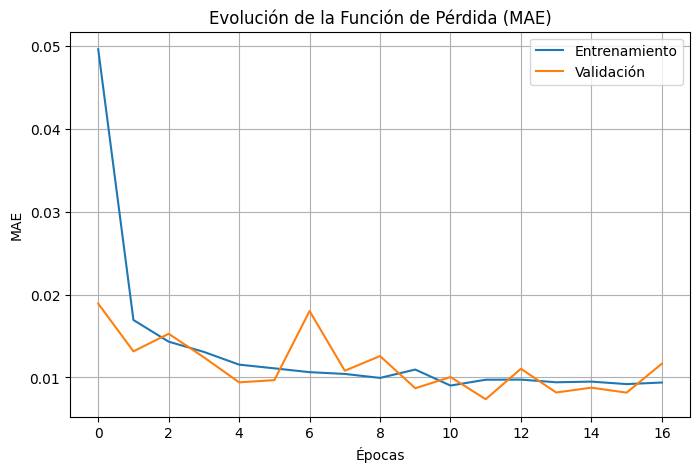

In [177]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')

plt.title('Evolución de la Función de Pérdida (MAE)')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.show()

* Se implementó la técnica Early Stopping con el objetivo de prevenir el **sobreajuste (overfitting)** durante el entrenamiento de la red neuronal. Este mecanismo monitorea la métrica val_loss (en este caso el **MAE** de validación) y detiene automáticamente el proceso de entrenamiento cuando dicha métrica deja de mejorar después de un número determinado de épocas, definido por el parámetro **patience = 5**.

* En otras palabras, si el error en los datos de validación no disminuye durante cinco iteraciones consecutivas, el modelo asume que ha alcanzado su punto óptimo de aprendizaje y detiene el entrenamiento. Esto evita que la red continúe ajustándose excesivamente a los datos de entrenamiento y ayuda a mejorar la capacidad de generalización sobre datos no vistos.

### **Coeficiente de determinación**

In [187]:
from sklearn.metrics import r2_score

In [188]:
def r2(y_true, y_pred):

  y_true = y_scaler.inverse_transform(y_true)
  y_pred = y_scaler.inverse_transform(y_pred)

  return r2_score(y_true,y_pred)

In [190]:
r2_score(y_train_scaled,model.predict(X_train_scaled))

883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


0.9992499126653738

In [191]:
r2_score(y_test_scaled,model.predict(X_test_scaled))

295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.9993313855311015

In [192]:
r2_score(y_val_scaled,model.predict(X_val_scaled))

295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.9991432277488892

### **Error absoluto medio**

In [183]:
def mae(y_true, y_pred):

  y_true = y_scaler.inverse_transform(y_true)
  y_pred = y_scaler.inverse_transform(y_pred)

  return mean_absolute_error(y_true,y_pred)

In [184]:
mae(y_train_scaled,model.predict(X_train_scaled))

883/883 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


190.27075566288264

In [185]:
mae(y_test_scaled,model.predict(X_test_scaled))

295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


184.83964079919167

In [186]:
mae(y_val_scaled,model.predict(X_val_scaled))

295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


195.65380463521657

* La red neuronal propuesta logró **superar en rendimiento al modelo de regresión lineal múltiple**, evidenciando una mayor capacidad para capturar relaciones no lineales dentro de los datos. Sin embargo, es importante considerar que este tipo de modelos implica una mayor complejidad estructural y un costo computacional superior, tanto en tiempo de entrenamiento como en consumo de recursos.

* Adicionalmente, las redes neuronales presentan una menor **interpretabilidad** en comparación con modelos estadísticos tradicionales. Debido a la dificultad para explicar de forma directa cómo se generan las predicciones, suelen denominarse “modelos de caja negra”, ya que su proceso interno de decisión no es fácilmente comprensible para usuarios o clientes no técnicos.

* Por ello, aunque ofrecen un mejor **desempeño predictivo**, su implementación debe evaluarse considerando el equilibrio entre precisión, costo computacional e interpretabilidad.

| Modelo                               | MAE Train | MAE Test | MAE Validación |
|--------------------------------------|---------:|--------:|---------------:|
| Regresión Lineal Múltiple (sin log)  | 5873     | 5784    | 6033           |
| Regresión Lineal Múltiple (con log)  | 663      | 644     | 674            |
| Random Forest                        | 2685     | 2676    | 2702           |
| Gradient Boosting                    | 1092     | 1105    | 1129           |
| XGBoost                              | 958      | 973     | 991            |
| Red Neuronal (TensorFlow)            | 190      | 184     | 195            |



In [193]:
def Predict(Fabricante,Modelo,Motor,Combustible,Año,Kilometraje):
  x = pd.DataFrame(
      {
          'Fabricante':[Fabricante],
          'Modelo':[Modelo],
          'Motor':[Motor],
          'Combustible':[Combustible],
          'Año':[Año],
          'Kilometraje':[Kilometraje]
      }
  )

  return lmlog.predict(x)

In [194]:
Predict('Toyota','RAV4',2.4,'Petrol',2016,150000)

array([16610.55252056])

In [195]:
import joblib

In [196]:
joblib.dump(lm,'/content/drive/MyDrive/modelo/model.pkl')

['/content/drive/MyDrive/modelo/model.pkl']

## **Conclusión**

* En este proyecto se evaluaron diversos algoritmos de machine learning para la predicción del precio de vehículos, entre ellos **Regresión Lineal Múltiple, Random Forest, Gradient Boosting, XGBoost** y **Redes Neuronales.** Inicialmente, la regresión lineal múltiple mostró un desempeño superior frente a modelos más complejos cuando se aplicó una transformación logarítmica a la variable objetivo, logrando una reducción sustancial del error absoluto medio (MAE).

* La **transformación logarítmica del precio** representó uno de los hallazgos más relevantes del estudio, ya que permitió estabilizar la varianza, reducir la influencia de valores atípicos y revelar una estructura predominantemente log-lineal en los datos. Este resultado demuestra que una adecuada ingeniería de variables puede generar mejoras incluso mayores que el simple cambio de algoritmo.

* Por su parte, **XGBoost** ofreció un rendimiento competitivo y una buena capacidad de generalización. Si bien no superó directamente a la regresión lineal transformada, su amplio rango de hiperparámetros sugiere que, con una optimización más exhaustiva, podría alcanzar niveles de precisión cercanos a modelos más complejos sin requerir necesariamente un escalado estricto de datos.

* El modelo de **Red Neuronal con TensorFlow** obtuvo el **menor MAE** de todos los enfoques evaluados, demostrando una notable capacidad para capturar relaciones no lineales y patrones complejos. No obstante, este tipo de modelos presenta mayor costo computacional, requiere un **preprocesamiento más riguroso** (como escalado de variables y transformaciones inversas para interpretar resultados) y posee una **baja interpretabilidad**, razón por la cual suelen denominarse **“modelos de caja negra”** dentro del ámbito estadístico.

* En términos prácticos, la elección del modelo no debe basarse únicamente en la métrica de error más baja, sino también en factores como interpretabilidad, costo computacional, **facilidad de implementación** y **necesidades del cliente.** Mientras que las redes neuronales ofrecen la mayor precisión, modelos como la regresión lineal transformada o XGBoost pueden representar un equilibrio más adecuado entre rendimiento y explicabilidad.

* En conclusión, este estudio refuerza que la **calidad del preprocesamiento** y la **correcta formulación del problema** son elementos determinantes en ciencia de datos. Modelos simples bien ajustados pueden competir con algoritmos avanzados, y la mejor solución no siempre es la más compleja, sino aquella que logra un balance óptimo entre **precisión, interpretabilidad y eficiencia computacional.**
